# Notebook 3 — Naive Bayes filtrado vs. sin filtro

Este notebook compara dos clasificadores multiclase de clústeres usando únicamente
la suma de log-odds de Naive Bayes sobre variables binarizadas/categorizadas.

## Modelos

### 1. `NB_FILTERED`

Usa la unión de variables que tienen al menos una categoría/bin que supera el
mismo filtro utilizado antes de XGBoost:

- `n_cluster_x >= MIN_N_CLUSTER_X`
- `score >= MIN_SCORE`
- `coverage_in_cluster >= MIN_COVERAGE`

### 2. `NB_UNFILTERED`

Usa todas las variables procesadas en
`bayes_internal_operations_all_variables.xlsx`, sin aplicar esos tres umbrales.

Las exclusiones científicas, identificadores y representaciones técnicas se
mantienen en ambos modelos.

## Evaluación

No se usa validación cruzada ni conjunto de prueba. Las métricas son
**aparentes/in-sample** y, por tanto, optimistas.

In [1]:
# =============================================================================
# 1. IMPORTACIONES, PROYECTO Y HANDOFF
# =============================================================================
from pathlib import Path
import importlib
import json
import math
import re
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    cohen_kappa_score,
    confusion_matrix,
    f1_score,
    fbeta_score,
    log_loss,
    matthews_corrcoef,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)

try:
    from tqdm.auto import tqdm
except Exception:
    def tqdm(iterable, **kwargs):
        return iterable

try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
    set_matplotlib_formats("svg")
except Exception:
    pass

warnings.filterwarnings(
    "ignore",
    message="DataFrame is highly fragmented",
)

_current = Path.cwd().expanduser().resolve()

PROJECT_ROOT = next(
    (
        candidate
        for candidate in [_current, *_current.parents]
        if (candidate / "src" / "ensanut_hba1c").is_dir()
        and (candidate / "data" / "input").is_dir()
    ),
    None,
)

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "No se encontró la raíz del proyecto. Guarda este Notebook 3 dentro "
        "del proyecto ENSANUT que contiene src/ensanut_hba1c y data/input."
    )

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

for module_name in list(sys.modules):
    if module_name == "ensanut_hba1c" or module_name.startswith("ensanut_hba1c."):
        sys.modules.pop(module_name, None)

importlib.invalidate_caches()

from ensanut_hba1c.paths import ProjectPaths
from ensanut_hba1c.io import load_notebook_handoff

PATHS = ProjectPaths(PROJECT_ROOT).ensure()

HANDOFF_DIR = PATHS.handoff_dir
NOTEBOOK1_OUTPUT_DIR = PATHS.notebook1_results
NOTEBOOK2_OUTPUT_DIR = PATHS.notebook2_results
OUTPUT_DIR = (
    PATHS.notebook2_results.parent
    / "03_naive_bayes_filtered_vs_unfiltered_no_cv"
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CLUSTER_COLUMN = "Cluster_SHAP"
ID_COLUMNS = ["FOLIO_I", "FOLIO_INT"]

EXTERNAL_CLUSTER_DATASET_PATH = None
EXTERNAL_DICTIONARY_PATH = None

fallback_cluster_paths = [
    NOTEBOOK1_OUTPUT_DIR / "complete_cluster_dataset.pkl",
    NOTEBOOK1_OUTPUT_DIR / "complete_cluster_dataset.csv",
]
fallback_dictionary_paths = [
    PATHS.input_dir / "ENSANUT_2024.csv",
]

if EXTERNAL_CLUSTER_DATASET_PATH is not None:
    fallback_cluster_paths.insert(
        0,
        Path(EXTERNAL_CLUSTER_DATASET_PATH).expanduser(),
    )

if EXTERNAL_DICTIONARY_PATH is not None:
    fallback_dictionary_paths.insert(
        0,
        Path(EXTERNAL_DICTIONARY_PATH).expanduser(),
    )

cluster_df, data_dictionary_df, handoff_metadata, handoff_sources = (
    load_notebook_handoff(
        HANDOFF_DIR,
        fallback_cluster_paths=fallback_cluster_paths,
        fallback_dictionary_paths=fallback_dictionary_paths,
        auto_discover_search_roots=[
            PROJECT_ROOT.parent,
            PROJECT_ROOT.parent.parent,
        ],
        auto_discover_max_depth=5,
        persist_recovered_handoff=True,
        cluster_column=CLUSTER_COLUMN,
    )
)

if CLUSTER_COLUMN not in cluster_df.columns:
    raise KeyError(
        f"No existe {CLUSTER_COLUMN!r} en el conjunto cargado."
    )

RUN_CONTEXT = pd.DataFrame([{
    "project_root": str(PROJECT_ROOT),
    "participants": len(cluster_df),
    "variables": cluster_df.shape[1],
    "clusters": cluster_df[CLUSTER_COLUMN].nunique(dropna=True),
    "cluster_source": str(handoff_sources["cluster"]),
    "output_dir": str(OUTPUT_DIR),
}])

display(RUN_CONTEXT)

/opt/anaconda3/envs/ensanut/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,project_root,participants,variables,clusters,cluster_source,output_dir
0,/Users/cristianjuliocesarpadronmanrique/Deskto...,2530,2765,10,/Users/cristianjuliocesarpadronmanrique/Deskto...,/Users/cristianjuliocesarpadronmanrique/Deskto...


In [2]:
# =============================================================================
# 2. PARÁMETROS EDITABLES Y EXCLUSIONES
# =============================================================================

# Mismo filtro principal utilizado antes de XGBoost.
MIN_N_CLUSTER_X = 10
MIN_SCORE = 0.40
MIN_COVERAGE = 0.07

# Parámetros NB.
NB_ALPHA = 1.0
NB_N_BINS = 10
NB_MAX_CATEGORICAL_LEVELS = 50
NB_MIN_RARE_LEVEL_COUNT = 2

# Salidas.
SHOW_PROGRESS = True
SHOW_PLOTS = True
EXPORT_EXCEL = True
EXPORT_CSV = True
EXPORT_RULE_LOG_ODDS_CSV = True
FIGURE_DPI = 220

# -------------------------------------------------------------------------
# Exclusiones científicas del Notebook 2
# -------------------------------------------------------------------------
REDUNDANT_AGE_COLUMNS = [
    "gpoedad",
    "annac",
    "mesnac",
    "fecha_nacimiento",
    "H0304A",
    "H0304M",
    "FECH_NAC",
    "edad",
    "AEDAD",
    "A0302",
    "MESES",
]

TARGET_DERIVED_COLUMNS = [
    "hba1c_class_cat",
    "hba1c_class_bin",
    "clasif_hba1c_cat",
    "clasif_hba1c_bin",
    "preferred_combined_class_bin",
    "preferred_combined_class_cat",
    "clasif_combinada_pref_bin",
    "clasif_combinada_pref_cat",
    "HbA1c_Status",
    "Estado_HbA1c",
]

DIRECT_OUTCOME_OR_LEAKAGE_COLUMNS = [
    "HB1AC",
    # "GLU_SUERO",  # Descomenta para excluir glucosa.
    "Metabolic_Syndrome_Status",
]

NOTEBOOK3_EXTRA_EXCLUDE_VARIABLES = [
    # "VAR001",
]

AUTOMATIC_EXCLUDE_COLUMNS = [
    *ID_COLUMNS,
    CLUSTER_COLUMN,
    "Cluster_SHAP_macro",
    "_merge",
    *[
        column
        for column in cluster_df.columns
        if column.startswith("PCA_")
        or column.startswith("UMAP_VISUAL_")
        or column.startswith("UMAP_GRAPH_PHATE_")
        or column.startswith("Mellon_")
    ],
]

PROHIBITED_VARIABLES = sorted(set(
    REDUNDANT_AGE_COLUMNS
    + TARGET_DERIVED_COLUMNS
    + DIRECT_OUTCOME_OR_LEAKAGE_COLUMNS
    + NOTEBOOK3_EXTRA_EXCLUDE_VARIABLES
    + AUTOMATIC_EXCLUDE_COLUMNS
))

print("Umbrales del filtro:")
print(f"  n_cluster_x >= {MIN_N_CLUSTER_X}")
print(f"  score >= {MIN_SCORE:.2f}")
print(f"  coverage_in_cluster >= {MIN_COVERAGE:.1%}")
print(f"Variables prohibidas: {len(PROHIBITED_VARIABLES):,}")

Umbrales del filtro:
  n_cluster_x >= 10
  score >= 0.40
  coverage_in_cluster >= 7.0%
Variables prohibidas: 82


In [3]:
# =============================================================================
# 3. CONSTRUIR LOS DOS CONJUNTOS DE VARIABLES
# =============================================================================

NB_WORKBOOK_CANDIDATES = [
    NOTEBOOK2_OUTPUT_DIR
    / "bayes_internal_operations_all_variables.xlsx"
]

NB_WORKBOOK_CANDIDATES.extend(
    sorted(
        PROJECT_ROOT.glob(
            "**/bayes_internal_operations_all_variables.xlsx"
        )
    )
)

NB_OPERATIONS_WORKBOOK = next(
    (
        candidate
        for candidate in NB_WORKBOOK_CANDIDATES
        if candidate.is_file()
    ),
    None,
)

if NB_OPERATIONS_WORKBOOK is None:
    raise FileNotFoundError(
        "No se encontró bayes_internal_operations_all_variables.xlsx. "
        "Ejecuta el Notebook 2 hasta generar ese archivo."
    )

NB_EVIDENCE_DF = pd.read_excel(
    NB_OPERATIONS_WORKBOOK,
    sheet_name="NB_internal_operations",
)

required_columns = [
    "cluster",
    "var",
    "n_cluster",
    "n_cluster_x",
    "score",
]
missing_columns = [
    column
    for column in required_columns
    if column not in NB_EVIDENCE_DF.columns
]
if missing_columns:
    raise ValueError(
        "Faltan columnas en NB_internal_operations: "
        f"{missing_columns}"
    )

for column in [
    "cluster",
    "n_cluster",
    "n_cluster_x",
    "score",
]:
    NB_EVIDENCE_DF[column] = pd.to_numeric(
        NB_EVIDENCE_DF[column],
        errors="coerce",
    )

NB_EVIDENCE_DF["var"] = (
    NB_EVIDENCE_DF["var"]
    .astype("string")
    .str.strip()
)

NB_EVIDENCE_DF["coverage_in_cluster"] = (
    NB_EVIDENCE_DF["n_cluster_x"]
    / NB_EVIDENCE_DF["n_cluster"]
)

NB_EVIDENCE_DF = (
    NB_EVIDENCE_DF
    .replace([np.inf, -np.inf], np.nan)
    .dropna(
        subset=[
            "cluster",
            "var",
            "n_cluster",
            "n_cluster_x",
            "score",
            "coverage_in_cluster",
        ]
    )
    .copy()
)

# Barrera de seguridad para libros de operaciones generados anteriormente.
NB_EVIDENCE_DF = NB_EVIDENCE_DF.loc[
    ~NB_EVIDENCE_DF["var"].astype(str).isin(PROHIBITED_VARIABLES)
].copy()

# -------------------------------------------------------------------------
# Con filtro: unión de variables con al menos una regla elegible.
# -------------------------------------------------------------------------
NB_FILTERED_EVIDENCE = NB_EVIDENCE_DF.loc[
    (NB_EVIDENCE_DF["n_cluster_x"] >= MIN_N_CLUSTER_X)
    & (NB_EVIDENCE_DF["score"] >= MIN_SCORE)
    & (
        NB_EVIDENCE_DF["coverage_in_cluster"]
        >= MIN_COVERAGE
    )
].copy()

if NB_FILTERED_EVIDENCE.empty:
    raise ValueError(
        "Ninguna regla superó el filtro principal."
    )

NB_FILTERED_VARIABLES = [
    variable
    for variable in dict.fromkeys(
        NB_FILTERED_EVIDENCE["var"].astype(str).tolist()
    )
    if variable in cluster_df.columns
    and variable not in PROHIBITED_VARIABLES
]

# -------------------------------------------------------------------------
# Sin filtro: todas las variables presentes en las operaciones NB.
# -------------------------------------------------------------------------
NB_UNFILTERED_VARIABLES = [
    variable
    for variable in dict.fromkeys(
        NB_EVIDENCE_DF["var"].astype(str).tolist()
    )
    if variable in cluster_df.columns
    and variable not in PROHIBITED_VARIABLES
]

NB_REJECTED_BY_FILTER_VARIABLES = sorted(
    set(NB_UNFILTERED_VARIABLES)
    .difference(NB_FILTERED_VARIABLES)
)

if not NB_FILTERED_VARIABLES:
    raise RuntimeError(
        "No quedaron variables filtradas presentes en cluster_df."
    )

if not NB_UNFILTERED_VARIABLES:
    raise RuntimeError(
        "No quedaron variables sin filtro presentes en cluster_df."
    )

NB_VARIABLE_SET_AUDIT = pd.DataFrame({
    "variable": sorted(set(NB_UNFILTERED_VARIABLES)),
})
NB_VARIABLE_SET_AUDIT["in_filtered_model"] = (
    NB_VARIABLE_SET_AUDIT["variable"]
    .isin(NB_FILTERED_VARIABLES)
)
NB_VARIABLE_SET_AUDIT["in_unfiltered_model"] = True
NB_VARIABLE_SET_AUDIT["rejected_by_main_filter"] = (
    ~NB_VARIABLE_SET_AUDIT["in_filtered_model"]
)

FILTER_SUMMARY = pd.DataFrame([
    {
        "model": "NB_FILTERED",
        "variables": len(NB_FILTERED_VARIABLES),
        "filter_applied": True,
        "min_n_cluster_x": MIN_N_CLUSTER_X,
        "min_score": MIN_SCORE,
        "min_coverage": MIN_COVERAGE,
    },
    {
        "model": "NB_UNFILTERED",
        "variables": len(NB_UNFILTERED_VARIABLES),
        "filter_applied": False,
        "min_n_cluster_x": np.nan,
        "min_score": np.nan,
        "min_coverage": np.nan,
    },
])

display(FILTER_SUMMARY)
print(
    "Variables rechazadas por el filtro pero usadas en NB_UNFILTERED:",
    f"{len(NB_REJECTED_BY_FILTER_VARIABLES):,}",
)
print("Libro NB:", NB_OPERATIONS_WORKBOOK)

,model,variables,filter_applied,min_n_cluster_x,min_score,min_coverage
0,NB_FILTERED,551,True,10.0,0.4,0.07
1,NB_UNFILTERED,1390,False,NaN,NaN,NaN


Variables rechazadas por el filtro pero usadas en NB_UNFILTERED: 839
Libro NB: /Users/cristianjuliocesarpadronmanrique/Desktop/ensanut preparation/prueba limpia/ENSANUT_HbA1c_complete_project/results/02_naive_bayes/bayes_internal_operations_all_variables.xlsx


In [4]:
# =============================================================================
# 4. FUNCIONES DEL CLASIFICADOR NB LOG-ODDS
# =============================================================================

def canonical_cluster_label(value):
    """Convierte 0, 0.0 o C0 a C0 y conserva etiquetas no numéricas."""
    if pd.isna(value):
        return np.nan

    text = str(value).strip()
    match = re.fullmatch(
        r"[Cc]?\s*(-?\d+(?:\.0+)?)",
        text,
    )

    if match:
        number = float(match.group(1))
        if number.is_integer():
            return f"C{int(number)}"

    return text


def cluster_sort_key(label):
    text = str(label)
    match = re.fullmatch(r"[Cc](-?\d+)", text)
    if match:
        return (0, int(match.group(1)))
    return (1, text)


def safe_numeric(series):
    cleaned = series.copy()

    if (
        cleaned.dtype == object
        or pd.api.types.is_string_dtype(cleaned)
    ):
        cleaned = (
            cleaned
            .astype("string")
            .str.strip()
            .replace({
                "": pd.NA,
                "nan": pd.NA,
                "NaN": pd.NA,
                "None": pd.NA,
                "NA": pd.NA,
                "N/A": pd.NA,
            })
        )

    return pd.to_numeric(cleaned, errors="coerce")


def format_edge(value):
    if not np.isfinite(value):
        return str(value)

    magnitude = abs(float(value))

    if magnitude >= 1000:
        return f"{value:,.1f}"
    if magnitude >= 100:
        return f"{value:.1f}"
    if magnitude >= 10:
        return f"{value:.2f}"

    return f"{value:.3f}"


def bin_single_variable(
    series,
    *,
    n_bins,
    max_categorical_levels,
    min_rare_count,
):
    original = series.copy()
    nonmissing = original.notna()
    n_nonmissing = int(nonmissing.sum())
    n_unique_raw = int(
        original[nonmissing].nunique(dropna=True)
    )

    numeric = safe_numeric(original)
    numeric_fraction = (
        float(numeric.notna().sum()) / n_nonmissing
        if n_nonmissing
        else 0.0
    )
    numeric_unique = int(numeric.nunique(dropna=True))

    numeric_threshold = max(12, 2 * int(n_bins))
    treat_as_numeric = (
        numeric_fraction >= 0.95
        and numeric_unique >= numeric_threshold
    )

    audit = {
        "variable": str(series.name),
        "n_rows": int(len(series)),
        "n_nonmissing": n_nonmissing,
        "n_missing": int(len(series) - n_nonmissing),
        "n_unique_raw": n_unique_raw,
        "numeric_fraction": numeric_fraction,
        "encoding": None,
        "n_output_levels": None,
        "cut_edges": None,
    }

    result = None

    if treat_as_numeric:
        q = max(2, min(int(n_bins), numeric_unique))

        try:
            _, edges = pd.qcut(
                numeric.dropna(),
                q=q,
                duplicates="drop",
                retbins=True,
            )
            edges = np.unique(
                np.asarray(edges, dtype=float)
            )
        except Exception:
            edges = np.array([], dtype=float)

        if len(edges) >= 3:
            labels = [
                (
                    f"Q{i + 1:02d} "
                    f"[{format_edge(edges[i])}, "
                    f"{format_edge(edges[i + 1])}]"
                )
                for i in range(len(edges) - 1)
            ]

            result = (
                pd.cut(
                    numeric,
                    bins=edges,
                    labels=labels,
                    include_lowest=True,
                    duplicates="drop",
                )
                .astype("string")
                .fillna("__MISSING__")
                .astype(str)
            )

            audit["encoding"] = "quantile"
            audit["cut_edges"] = json.dumps(
                [float(x) for x in edges],
                ensure_ascii=False,
            )

    if result is None:
        result = (
            original
            .astype("string")
            .str.strip()
            .replace({
                "": pd.NA,
                "nan": pd.NA,
                "NaN": pd.NA,
                "None": pd.NA,
                "NA": pd.NA,
                "N/A": pd.NA,
            })
            .fillna("__MISSING__")
            .astype(str)
        )

        counts = result.value_counts(dropna=False)

        if len(counts) > max_categorical_levels:
            keep = set(
                counts
                .head(
                    max(
                        1,
                        max_categorical_levels - 2,
                    )
                )
                .index
                .astype(str)
            )
            keep.add("__MISSING__")
            result = result.where(
                result.isin(keep),
                "__OTHER__",
            )

        if min_rare_count > 1:
            counts = result.value_counts(dropna=False)
            rare = set(
                counts.loc[
                    (counts < int(min_rare_count))
                    & (
                        counts.index
                        != "__MISSING__"
                    )
                ]
                .index
                .astype(str)
            )

            if rare:
                result = result.where(
                    ~result.isin(rare),
                    "__OTHER__",
                )

        audit["encoding"] = "categorical"

    result = result.astype(str)
    audit["n_output_levels"] = int(
        result.nunique(dropna=False)
    )

    return result, audit


def stable_softmax(logits):
    logits = np.asarray(logits, dtype=float)
    shifted = logits - np.max(logits, axis=1, keepdims=True)
    exponentials = np.exp(np.clip(shifted, -700, 700))
    denominator = exponentials.sum(axis=1, keepdims=True)
    denominator[denominator == 0] = 1.0
    return exponentials / denominator


def mean_or_nan(values, weights=None):
    values = np.asarray(values, dtype=float)
    valid = np.isfinite(values)

    if not valid.any():
        return np.nan

    if weights is None:
        return float(np.mean(values[valid]))

    weights = np.asarray(weights, dtype=float)[valid]

    if weights.sum() <= 0:
        return float(np.mean(values[valid]))

    return float(
        np.average(
            values[valid],
            weights=weights,
        )
    )


def safe_roc_auc(y_binary, probability):
    y_binary = np.asarray(y_binary, dtype=int)
    probability = np.asarray(probability, dtype=float)

    if np.unique(y_binary).size < 2:
        return np.nan

    return float(
        roc_auc_score(
            y_binary,
            probability,
        )
    )


def safe_pr_auc(y_binary, probability):
    y_binary = np.asarray(y_binary, dtype=int)
    probability = np.asarray(probability, dtype=float)

    if y_binary.sum() == 0:
        return np.nan

    return float(
        average_precision_score(
            y_binary,
            probability,
        )
    )


def plot_confusion_matrix(
    confusion_df,
    model_label,
    output_dir,
):
    classes = list(confusion_df.index)
    values = confusion_df.to_numpy()

    fig, ax = plt.subplots(figsize=(8.2, 7.0))
    image = ax.imshow(values, aspect="auto")

    ax.set_xticks(np.arange(len(classes)))
    ax.set_yticks(np.arange(len(classes)))
    ax.set_xticklabels(classes, rotation=45, ha="right")
    ax.set_yticklabels(classes)
    ax.set_xlabel("Predicted cluster")
    ax.set_ylabel("Observed cluster")
    ax.set_title(
        f"{model_label} confusion matrix — apparent/no CV"
    )

    threshold = values.max() / 2.0 if values.size else 0.0

    for row_index in range(len(classes)):
        for column_index in range(len(classes)):
            value = int(values[row_index, column_index])
            ax.text(
                column_index,
                row_index,
                f"{value:,}",
                ha="center",
                va="center",
                color=(
                    "white"
                    if value > threshold
                    else "black"
                ),
                fontsize=7,
            )

    fig.colorbar(
        image,
        ax=ax,
        fraction=0.046,
        pad=0.04,
    )
    fig.tight_layout()

    png_path = output_dir / "confusion_matrix.png"
    pdf_path = output_dir / "confusion_matrix.pdf"

    fig.savefig(
        png_path,
        dpi=FIGURE_DPI,
        bbox_inches="tight",
    )
    fig.savefig(
        pdf_path,
        bbox_inches="tight",
    )
    plt.show()
    plt.close(fig)

    return {
        "confusion_png": png_path,
        "confusion_pdf": pdf_path,
    }


def plot_roc_curves(
    y_true,
    probabilities,
    classes,
    model_label,
    output_dir,
):
    fig, ax = plt.subplots(figsize=(8.2, 7.0))

    for class_index, cluster_label in enumerate(classes):
        y_binary = (
            y_true == cluster_label
        ).astype(int)

        if np.unique(y_binary).size < 2:
            continue

        fpr, tpr, _ = roc_curve(
            y_binary,
            probabilities[:, class_index],
        )
        auc_value = safe_roc_auc(
            y_binary,
            probabilities[:, class_index],
        )

        ax.plot(
            fpr,
            tpr,
            linewidth=1.2,
            label=(
                f"{cluster_label} "
                f"(AUC={auc_value:.3f})"
            ),
        )

    ax.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        linewidth=1,
    )
    ax.set_xlabel("False-positive rate")
    ax.set_ylabel("True-positive rate")
    ax.set_title(
        f"{model_label} ROC curves — apparent/no CV"
    )
    ax.legend(
        loc="lower right",
        fontsize=7,
        ncol=2,
        frameon=False,
    )
    fig.tight_layout()

    png_path = output_dir / "roc_curves_ovr.png"
    pdf_path = output_dir / "roc_curves_ovr.pdf"

    fig.savefig(
        png_path,
        dpi=FIGURE_DPI,
        bbox_inches="tight",
    )
    fig.savefig(
        pdf_path,
        bbox_inches="tight",
    )
    plt.show()
    plt.close(fig)

    return {
        "roc_png": png_path,
        "roc_pdf": pdf_path,
    }


def plot_precision_recall_curves(
    y_true,
    probabilities,
    classes,
    model_label,
    output_dir,
):
    fig, ax = plt.subplots(figsize=(8.2, 7.0))

    for class_index, cluster_label in enumerate(classes):
        y_binary = (
            y_true == cluster_label
        ).astype(int)

        if y_binary.sum() == 0:
            continue

        precision_curve, recall_curve, _ = (
            precision_recall_curve(
                y_binary,
                probabilities[:, class_index],
            )
        )
        ap_value = safe_pr_auc(
            y_binary,
            probabilities[:, class_index],
        )

        ax.plot(
            recall_curve,
            precision_curve,
            linewidth=1.2,
            label=(
                f"{cluster_label} "
                f"(AP={ap_value:.3f})"
            ),
        )

    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title(
        f"{model_label} precision-recall — apparent/no CV"
    )
    ax.legend(
        loc="best",
        fontsize=7,
        ncol=2,
        frameon=False,
    )
    fig.tight_layout()

    png_path = (
        output_dir
        / "precision_recall_curves_ovr.png"
    )
    pdf_path = (
        output_dir
        / "precision_recall_curves_ovr.pdf"
    )

    fig.savefig(
        png_path,
        dpi=FIGURE_DPI,
        bbox_inches="tight",
    )
    fig.savefig(
        pdf_path,
        bbox_inches="tight",
    )
    plt.show()
    plt.close(fig)

    return {
        "pr_png": png_path,
        "pr_pdf": pdf_path,
    }


def run_nb_logodds_model(
    *,
    model_name,
    candidate_variables,
    feature_source,
):
    model_output_dir = OUTPUT_DIR / model_name.lower()
    model_output_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    selected_variables = [
        str(variable)
        for variable in dict.fromkeys(candidate_variables)
        if str(variable) in cluster_df.columns
        and str(variable) not in PROHIBITED_VARIABLES
    ]

    if not selected_variables:
        raise RuntimeError(
            f"{model_name}: no quedaron variables elegibles."
        )

    available_id_columns = [
        column
        for column in ID_COLUMNS
        if column in cluster_df.columns
    ]

    analysis_columns = (
        available_id_columns
        + [CLUSTER_COLUMN]
        + selected_variables
    )

    analysis_df = (
        cluster_df
        .loc[:, analysis_columns]
        .copy()
    )
    analysis_df = (
        analysis_df
        .loc[
            analysis_df[CLUSTER_COLUMN].notna()
        ]
        .reset_index(drop=False)
        .rename(columns={"index": "_source_row"})
    )

    analysis_df["_cluster_label"] = (
        analysis_df[CLUSTER_COLUMN]
        .map(canonical_cluster_label)
    )
    analysis_df = (
        analysis_df
        .loc[
            analysis_df["_cluster_label"].notna()
        ]
        .reset_index(drop=True)
    )

    y_true = (
        analysis_df["_cluster_label"]
        .astype(str)
        .to_numpy()
    )
    classes = sorted(
        pd.unique(y_true).tolist(),
        key=cluster_sort_key,
    )

    if len(classes) < 2:
        raise RuntimeError(
            f"{model_name}: se requieren al menos dos clústeres."
        )

    encoded_columns = {}
    binning_audit_rows = []

    variable_iterator = selected_variables
    if SHOW_PROGRESS:
        variable_iterator = tqdm(
            variable_iterator,
            desc=f"{model_name}: binning",
        )

    for variable in variable_iterator:
        encoded, audit = bin_single_variable(
            analysis_df[variable],
            n_bins=NB_N_BINS,
            max_categorical_levels=(
                NB_MAX_CATEGORICAL_LEVELS
            ),
            min_rare_count=(
                NB_MIN_RARE_LEVEL_COUNT
            ),
        )
        encoded_columns[variable] = encoded
        binning_audit_rows.append(audit)

    binned_df = pd.DataFrame(
        encoded_columns,
        index=analysis_df.index,
    )
    binning_audit = pd.DataFrame(
        binning_audit_rows
    )

    invariant_variables = (
        binning_audit
        .loc[
            binning_audit["n_output_levels"] < 2,
            "variable",
        ]
        .astype(str)
        .tolist()
    )

    if invariant_variables:
        binned_df = binned_df.drop(
            columns=invariant_variables,
            errors="ignore",
        )

    model_variables = (
        binned_df.columns
        .astype(str)
        .tolist()
    )

    if not model_variables:
        raise RuntimeError(
            f"{model_name}: todas las variables fueron invariantes."
        )

    n_samples = len(analysis_df)
    n_classes = len(classes)
    alpha = float(NB_ALPHA)

    posterior_log_odds = np.zeros(
        (n_samples, n_classes),
        dtype=float,
    )
    nb_scores = np.zeros_like(
        posterior_log_odds
    )
    prior_logit_by_class = {}
    rule_rows = []

    class_iterator = enumerate(classes)
    if SHOW_PROGRESS:
        class_iterator = tqdm(
            list(class_iterator),
            desc=f"{model_name}: clusters",
        )

    for class_index, cluster_label in class_iterator:
        in_cluster = y_true == cluster_label
        out_cluster = ~in_cluster

        n_cluster = int(in_cluster.sum())
        n_rest = int(out_cluster.sum())

        prior_probability = (
            (n_cluster + alpha)
            / (n_samples + 2.0 * alpha)
        )
        prior_logit = math.log(
            prior_probability
            / (1.0 - prior_probability)
        )
        prior_logit_by_class[
            cluster_label
        ] = prior_logit

        class_score = np.zeros(
            n_samples,
            dtype=float,
        )

        for variable in model_variables:
            observed = binned_df[
                variable
            ].astype(str)

            levels = sorted(
                observed.unique().tolist()
            )
            k_levels = max(1, len(levels))

            cluster_counts = (
                observed[in_cluster]
                .value_counts()
            )
            rest_counts = (
                observed[out_cluster]
                .value_counts()
            )

            level_to_log_ratio = {}

            for level in levels:
                n_cluster_x = int(
                    cluster_counts.get(level, 0)
                )
                n_rest_x = int(
                    rest_counts.get(level, 0)
                )

                p_x_given_cluster = (
                    (n_cluster_x + alpha)
                    / (
                        n_cluster
                        + alpha * k_levels
                    )
                )
                p_x_given_rest = (
                    (n_rest_x + alpha)
                    / (
                        n_rest
                        + alpha * k_levels
                    )
                )

                log_ratio = math.log(
                    p_x_given_cluster
                    / p_x_given_rest
                )
                level_to_log_ratio[
                    level
                ] = log_ratio

                if EXPORT_RULE_LOG_ODDS_CSV:
                    rule_rows.append({
                        "model": model_name,
                        "cluster": cluster_label,
                        "variable": variable,
                        "bin_or_category": level,
                        "n_total": n_samples,
                        "n_cluster": n_cluster,
                        "n_rest": n_rest,
                        "n_x": int(
                            (observed == level).sum()
                        ),
                        "n_cluster_x": n_cluster_x,
                        "n_rest_x": n_rest_x,
                        "p_x_given_cluster": (
                            p_x_given_cluster
                        ),
                        "p_x_given_rest": (
                            p_x_given_rest
                        ),
                        "nb_log_likelihood_ratio": (
                            log_ratio
                        ),
                        "direction": (
                            "NB+"
                            if log_ratio > 0
                            else "NB-"
                            if log_ratio < 0
                            else "neutral"
                        ),
                        "alpha": alpha,
                        "n_levels_variable": k_levels,
                    })

            class_score += (
                observed
                .map(level_to_log_ratio)
                .fillna(0.0)
                .to_numpy(dtype=float)
            )

        nb_scores[
            :,
            class_index,
        ] = class_score
        posterior_log_odds[
            :,
            class_index,
        ] = (
            prior_logit
            + class_score
        )

    normalized_probabilities = stable_softmax(
        posterior_log_odds
    )

    predicted_indices = (
        normalized_probabilities
        .argmax(axis=1)
    )
    y_pred = np.asarray(
        [
            classes[index]
            for index in predicted_indices
        ],
        dtype=object,
    )

    prediction_columns = (
        ["_source_row"]
        + available_id_columns
        + [
            CLUSTER_COLUMN,
            "_cluster_label",
        ]
    )
    participant_predictions = (
        analysis_df[
            prediction_columns
        ]
        .copy()
        .rename(
            columns={
                "_cluster_label": (
                    "observed_cluster"
                )
            }
        )
    )
    participant_predictions[
        "predicted_cluster"
    ] = y_pred
    participant_predictions[
        "correct"
    ] = (
        participant_predictions[
            "observed_cluster"
        ]
        == participant_predictions[
            "predicted_cluster"
        ]
    )
    participant_predictions[
        "max_normalized_probability"
    ] = normalized_probabilities.max(axis=1)

    sorted_probabilities = np.sort(
        normalized_probabilities,
        axis=1,
    )
    participant_predictions[
        "probability_margin"
    ] = (
        sorted_probabilities[:, -1]
        - sorted_probabilities[:, -2]
    )

    for class_index, cluster_label in enumerate(classes):
        participant_predictions[
            f"NB_score_{cluster_label}"
        ] = nb_scores[:, class_index]
        participant_predictions[
            f"prior_logit_{cluster_label}"
        ] = prior_logit_by_class[
            cluster_label
        ]
        participant_predictions[
            f"posterior_log_odds_{cluster_label}"
        ] = posterior_log_odds[
            :,
            class_index,
        ]
        participant_predictions[
            f"normalized_probability_{cluster_label}"
        ] = normalized_probabilities[
            :,
            class_index,
        ]

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=classes,
    )
    confusion_df = pd.DataFrame(
        cm,
        index=pd.Index(
            classes,
            name="observed_cluster",
        ),
        columns=pd.Index(
            classes,
            name="predicted_cluster",
        ),
    )

    per_cluster_rows = []
    per_class_roc_auc = []
    per_class_pr_auc = []
    class_supports = []

    for class_index, cluster_label in enumerate(classes):
        y_binary = (
            y_true == cluster_label
        ).astype(int)
        pred_binary = (
            y_pred == cluster_label
        ).astype(int)
        probability = normalized_probabilities[
            :,
            class_index,
        ]

        tn, fp, fn, tp = confusion_matrix(
            y_binary,
            pred_binary,
            labels=[0, 1],
        ).ravel()

        precision_value = (
            tp / (tp + fp)
            if (tp + fp)
            else 0.0
        )
        sensitivity_value = (
            tp / (tp + fn)
            if (tp + fn)
            else 0.0
        )
        specificity_value = (
            tn / (tn + fp)
            if (tn + fp)
            else np.nan
        )
        npv_value = (
            tn / (tn + fn)
            if (tn + fn)
            else np.nan
        )

        roc_auc_value = safe_roc_auc(
            y_binary,
            probability,
        )
        pr_auc_value = safe_pr_auc(
            y_binary,
            probability,
        )

        per_class_roc_auc.append(
            roc_auc_value
        )
        per_class_pr_auc.append(
            pr_auc_value
        )
        class_supports.append(
            int(tp + fn)
        )

        per_cluster_rows.append({
            "model": model_name,
            "cluster": cluster_label,
            "N": n_samples,
            "support": int(tp + fn),
            "prevalence": (
                (tp + fn) / n_samples
            ),
            "predicted_n": int(tp + fp),
            "predicted_fraction": (
                (tp + fp) / n_samples
            ),
            "TP": int(tp),
            "FP": int(fp),
            "FN": int(fn),
            "TN": int(tn),
            "precision_PPV": precision_value,
            "sensitivity_recall": (
                sensitivity_value
            ),
            "specificity": specificity_value,
            "NPV": npv_value,
            "F0.5": fbeta_score(
                y_binary,
                pred_binary,
                beta=0.5,
                zero_division=0,
            ),
            "F1": f1_score(
                y_binary,
                pred_binary,
                zero_division=0,
            ),
            "F2": fbeta_score(
                y_binary,
                pred_binary,
                beta=2.0,
                zero_division=0,
            ),
            "ROC_AUC_OVR": roc_auc_value,
            "PR_AUC_average_precision": (
                pr_auc_value
            ),
            "mean_probability_true_members": (
                float(
                    probability[
                        y_binary == 1
                    ].mean()
                )
                if y_binary.sum()
                else np.nan
            ),
            "mean_probability_nonmembers": (
                float(
                    probability[
                        y_binary == 0
                    ].mean()
                )
                if (y_binary == 0).sum()
                else np.nan
            ),
        })

    metrics_by_cluster = pd.DataFrame(
        per_cluster_rows
    )

    supports = np.asarray(
        class_supports,
        dtype=float,
    )
    specificities = (
        metrics_by_cluster[
            "specificity"
        ]
        .to_numpy(dtype=float)
    )

    y_indicator = np.column_stack([
        (
            y_true == cluster_label
        ).astype(int)
        for cluster_label in classes
    ])

    try:
        roc_auc_micro = float(
            roc_auc_score(
                y_indicator.ravel(),
                normalized_probabilities.ravel(),
            )
        )
    except Exception:
        roc_auc_micro = np.nan

    try:
        pr_auc_micro = float(
            average_precision_score(
                y_indicator.ravel(),
                normalized_probabilities.ravel(),
            )
        )
    except Exception:
        pr_auc_micro = np.nan

    global_metrics = pd.DataFrame([{
        "model": model_name,
        "evaluation": (
            "apparent_in_sample_no_cv"
        ),
        "feature_source": feature_source,
        "N": n_samples,
        "clusters": n_classes,
        "candidate_variables": (
            len(selected_variables)
        ),
        "model_variables": len(
            model_variables
        ),
        "accuracy": accuracy_score(
            y_true,
            y_pred,
        ),
        "balanced_accuracy": (
            balanced_accuracy_score(
                y_true,
                y_pred,
            )
        ),
        "precision_macro": precision_score(
            y_true,
            y_pred,
            labels=classes,
            average="macro",
            zero_division=0,
        ),
        "precision_weighted": (
            precision_score(
                y_true,
                y_pred,
                labels=classes,
                average="weighted",
                zero_division=0,
            )
        ),
        "recall_macro": recall_score(
            y_true,
            y_pred,
            labels=classes,
            average="macro",
            zero_division=0,
        ),
        "recall_weighted": recall_score(
            y_true,
            y_pred,
            labels=classes,
            average="weighted",
            zero_division=0,
        ),
        "specificity_macro": mean_or_nan(
            specificities
        ),
        "specificity_weighted": mean_or_nan(
            specificities,
            weights=supports,
        ),
        "F0.5_macro": fbeta_score(
            y_true,
            y_pred,
            labels=classes,
            average="macro",
            beta=0.5,
            zero_division=0,
        ),
        "F1_macro": f1_score(
            y_true,
            y_pred,
            labels=classes,
            average="macro",
            zero_division=0,
        ),
        "F1_weighted": f1_score(
            y_true,
            y_pred,
            labels=classes,
            average="weighted",
            zero_division=0,
        ),
        "F2_macro": fbeta_score(
            y_true,
            y_pred,
            labels=classes,
            average="macro",
            beta=2.0,
            zero_division=0,
        ),
        "ROC_AUC_macro_OVR": mean_or_nan(
            per_class_roc_auc
        ),
        "ROC_AUC_weighted_OVR": mean_or_nan(
            per_class_roc_auc,
            weights=supports,
        ),
        "ROC_AUC_micro_OVR": roc_auc_micro,
        "PR_AUC_macro": mean_or_nan(
            per_class_pr_auc
        ),
        "PR_AUC_weighted": mean_or_nan(
            per_class_pr_auc,
            weights=supports,
        ),
        "PR_AUC_micro": pr_auc_micro,
        "multiclass_log_loss": log_loss(
            y_true,
            normalized_probabilities,
            labels=classes,
        ),
        "Matthews_correlation_coefficient": (
            matthews_corrcoef(
                y_true,
                y_pred,
            )
        ),
        "Cohen_kappa": cohen_kappa_score(
            y_true,
            y_pred,
        ),
    }])

    classification_report_df = (
        pd.DataFrame(
            classification_report(
                y_true,
                y_pred,
                labels=classes,
                target_names=classes,
                output_dict=True,
                zero_division=0,
            )
        )
        .T
        .reset_index(names="row")
    )

    class_priors = pd.DataFrame([
        {
            "model": model_name,
            "cluster": cluster_label,
            "support": int(
                (
                    y_true
                    == cluster_label
                ).sum()
            ),
            "prevalence": float(
                (
                    y_true
                    == cluster_label
                ).mean()
            ),
            "prior_logit": (
                prior_logit_by_class[
                    cluster_label
                ]
            ),
        }
        for cluster_label in classes
    ])

    feature_list = pd.DataFrame({
        "model": model_name,
        "variable": model_variables,
        "feature_source": feature_source,
    })

    rule_log_odds = pd.DataFrame(
        rule_rows
    )

    output_paths = {}

    if EXPORT_CSV:
        tables = {
            "global_metrics": global_metrics,
            "metrics_by_cluster": metrics_by_cluster,
            "confusion_matrix": (
                confusion_df
                .reset_index()
            ),
            "classification_report": (
                classification_report_df
            ),
            "participant_predictions": (
                participant_predictions
            ),
            "binning_audit": binning_audit,
            "class_priors": class_priors,
            "feature_list": feature_list,
        }

        for table_name, table in tables.items():
            path = (
                model_output_dir
                / f"{table_name}.csv"
            )
            table.to_csv(
                path,
                index=False,
            )
            output_paths[
                table_name
            ] = path

        if (
            EXPORT_RULE_LOG_ODDS_CSV
            and not rule_log_odds.empty
        ):
            rules_path = (
                model_output_dir
                / "rule_log_odds.csv"
            )
            rule_log_odds.to_csv(
                rules_path,
                index=False,
            )
            output_paths[
                "rule_log_odds"
            ] = rules_path

    if EXPORT_EXCEL:
        excel_path = (
            model_output_dir
            / f"{model_name.lower()}_performance_no_cv.xlsx"
        )

        with pd.ExcelWriter(
            excel_path,
            engine="openpyxl",
        ) as writer:
            global_metrics.to_excel(
                writer,
                sheet_name="Global_metrics",
                index=False,
            )
            metrics_by_cluster.to_excel(
                writer,
                sheet_name="Metrics_by_cluster",
                index=False,
            )
            confusion_df.to_excel(
                writer,
                sheet_name="Confusion_matrix",
            )
            classification_report_df.to_excel(
                writer,
                sheet_name="Classification_report",
                index=False,
            )
            participant_predictions.to_excel(
                writer,
                sheet_name="Participant_predictions",
                index=False,
            )
            binning_audit.to_excel(
                writer,
                sheet_name="Binning_audit",
                index=False,
            )
            class_priors.to_excel(
                writer,
                sheet_name="Class_priors",
                index=False,
            )
            feature_list.to_excel(
                writer,
                sheet_name="Feature_list",
                index=False,
            )

        output_paths["excel"] = excel_path

    if SHOW_PLOTS:
        output_paths.update(
            plot_confusion_matrix(
                confusion_df,
                model_name,
                model_output_dir,
            )
        )
        output_paths.update(
            plot_roc_curves(
                y_true,
                normalized_probabilities,
                classes,
                model_name,
                model_output_dir,
            )
        )
        output_paths.update(
            plot_precision_recall_curves(
                y_true,
                normalized_probabilities,
                classes,
                model_name,
                model_output_dir,
            )
        )

    gm = global_metrics.iloc[0]

    print()
    print("=" * 82)
    print(
        f"{model_name} — APPARENT PERFORMANCE / NO CV"
    )
    print("=" * 82)
    print(
        f"Participants:                 "
        f"{int(gm['N']):,}"
    )
    print(
        f"Clusters:                     "
        f"{int(gm['clusters'])}"
    )
    print(
        f"Candidate variables:          "
        f"{int(gm['candidate_variables']):,}"
    )
    print(
        f"Model variables:              "
        f"{int(gm['model_variables']):,}"
    )
    print(
        f"Accuracy:                     "
        f"{gm['accuracy']:.4f}"
    )
    print(
        f"Balanced accuracy:            "
        f"{gm['balanced_accuracy']:.4f}"
    )
    print(
        f"Precision macro:              "
        f"{gm['precision_macro']:.4f}"
    )
    print(
        f"Precision weighted:           "
        f"{gm['precision_weighted']:.4f}"
    )
    print(
        f"Recall macro:                 "
        f"{gm['recall_macro']:.4f}"
    )
    print(
        f"Specificity macro:            "
        f"{gm['specificity_macro']:.4f}"
    )
    print(
        f"F1 macro:                     "
        f"{gm['F1_macro']:.4f}"
    )
    print(
        f"F1 weighted:                  "
        f"{gm['F1_weighted']:.4f}"
    )
    print(
        f"ROC-AUC macro OVR:            "
        f"{gm['ROC_AUC_macro_OVR']:.4f}"
    )
    print(
        f"ROC-AUC weighted OVR:         "
        f"{gm['ROC_AUC_weighted_OVR']:.4f}"
    )
    print(
        f"PR-AUC macro:                 "
        f"{gm['PR_AUC_macro']:.4f}"
    )
    print(
        f"PR-AUC weighted:              "
        f"{gm['PR_AUC_weighted']:.4f}"
    )
    print(
        f"Multiclass log loss:          "
        f"{gm['multiclass_log_loss']:.4f}"
    )
    print(
        f"Matthews correlation:         "
        f"{gm['Matthews_correlation_coefficient']:.4f}"
    )
    print(
        f"Cohen kappa:                  "
        f"{gm['Cohen_kappa']:.4f}"
    )
    print("-" * 82)
    print(
        "WARNING: in-sample/apparent metrics; "
        "the same records estimate and evaluate NB."
    )
    print("=" * 82)

    display(
        global_metrics
        .T
        .rename(
            columns={
                0: model_name
            }
        )
    )
    display(
        metrics_by_cluster
        .sort_values(
            "cluster",
            key=lambda series: (
                series.map(cluster_sort_key)
            ),
        )
        .reset_index(drop=True)
    )
    display(confusion_df)

    return {
        "model_name": model_name,
        "global_metrics": global_metrics,
        "metrics_by_cluster": metrics_by_cluster,
        "confusion_matrix": confusion_df,
        "classification_report": (
            classification_report_df
        ),
        "participant_predictions": (
            participant_predictions
        ),
        "rule_log_odds": rule_log_odds,
        "binning_audit": binning_audit,
        "class_priors": class_priors,
        "feature_list": feature_list,
        "classes": classes,
        "probabilities": (
            normalized_probabilities
        ),
        "output_paths": output_paths,
    }

# EJECUTAR LOS DOS MODELOS AQUÍ

Ejecuta la siguiente celda para correr `NB_FILTERED` y `NB_UNFILTERED`.

NB_FILTERED: clusters: 100%|███████████████████| 10/10 [00:08<00:00,  1.20it/s]


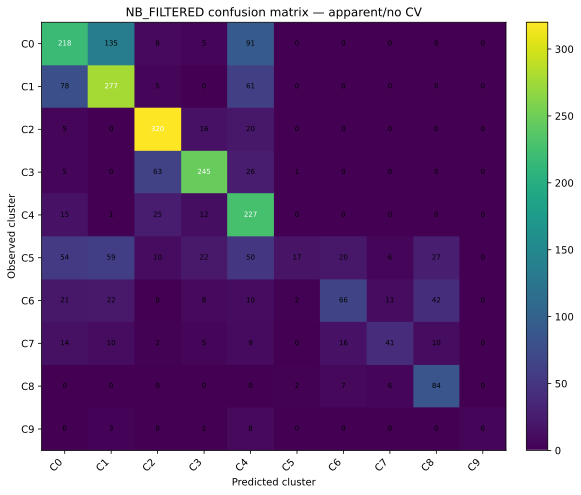

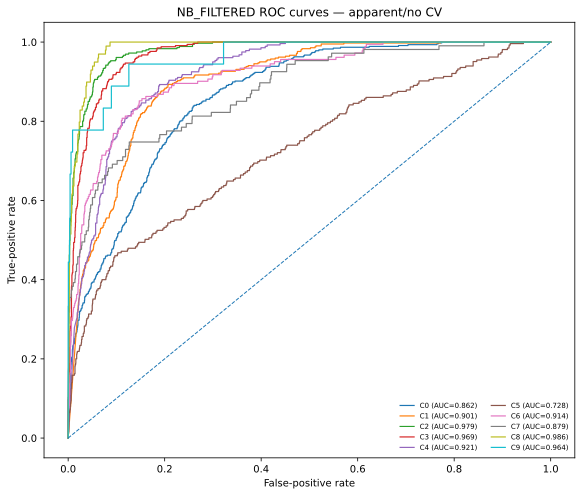

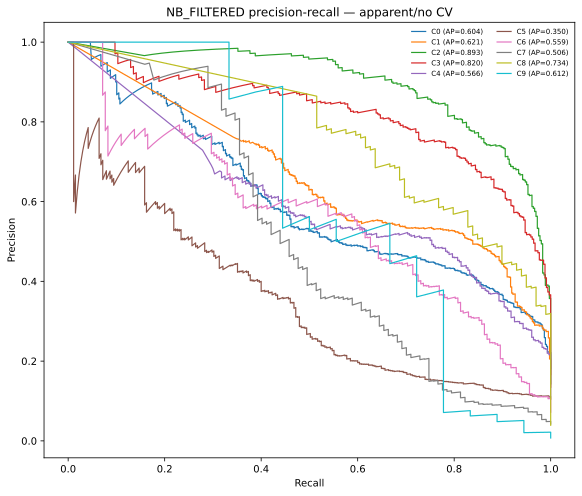


NB_FILTERED — APPARENT PERFORMANCE / NO CV
Participants:                 2,530
Clusters:                     10
Candidate variables:          551
Model variables:              551
Accuracy:                     0.5933
Balanced accuracy:            0.5544
Precision macro:              0.6584
Precision weighted:           0.6262
Recall macro:                 0.5544
Specificity macro:            0.9530
F1 macro:                     0.5429
F1 weighted:                  0.5641
ROC-AUC macro OVR:            0.9106
ROC-AUC weighted OVR:         0.9024
PR-AUC macro:                 0.6266
PR-AUC weighted:              0.6443
Multiclass log loss:          8.7295
Matthews correlation:         0.5373
Cohen kappa:                  0.5307
----------------------------------------------------------------------------------


,NB_FILTERED
model,NB_FILTERED
evaluation,apparent_in_sample_no_cv
feature_source,Variables with >=1 NB rule passing n_cluster_x...
N,2530
clusters,10
candidate_variables,551
model_variables,551
accuracy,0.593281
balanced_accuracy,0.554449
precision_macro,0.658373


,model,cluster,N,support,prevalence,predicted_n,predicted_fraction,TP,FP,FN,...,sensitivity_recall,specificity,NPV,F0.5,F1,F2,ROC_AUC_OVR,PR_AUC_average_precision,mean_probability_true_members,mean_probability_nonmembers
0,NB_FILTERED,C0,2530,457,0.180632,410,0.162055,218,192,239,...,0.477024,0.907381,0.887264,0.519790,0.502884,0.487042,0.862490,0.604224,0.481521,9.165121e-02
1,NB_FILTERED,C1,2530,421,0.166403,507,0.200395,277,230,144,...,0.657957,0.890944,0.928819,0.565537,0.596983,0.632131,0.900850,0.621373,0.655319,1.086237e-01
2,NB_FILTERED,C2,2530,361,0.142688,433,0.171146,320,113,41,...,0.886427,0.947902,0.980448,0.764453,0.806045,0.852424,0.979426,0.893420,0.885074,5.209613e-02
3,NB_FILTERED,C3,2530,340,0.134387,314,0.124111,245,69,95,...,0.720588,0.968493,0.957130,0.767544,0.749235,0.731780,0.969346,0.820497,0.714196,3.235536e-02
4,NB_FILTERED,C4,2530,280,0.110672,502,0.198419,227,275,53,...,0.810714,0.877778,0.973866,0.496066,0.580563,0.699753,0.921287,0.566160,0.808657,1.230588e-01
5,NB_FILTERED,C5,2530,265,0.104743,22,0.008696,17,5,248,...,0.064151,0.997792,0.901116,0.240793,0.118467,0.078558,0.728389,0.350205,0.062391,2.807571e-03
6,NB_FILTERED,C6,2530,182,0.071937,109,0.043083,66,43,116,...,0.362637,0.981687,0.952086,0.533981,0.453608,0.394265,0.914187,0.558985,0.357853,1.783870e-02
7,NB_FILTERED,C7,2530,107,0.042292,64,0.025296,41,23,66,...,0.383178,0.990508,0.973236,0.564738,0.479532,0.416667,0.879226,0.506194,0.384810,9.683475e-03
8,NB_FILTERED,C8,2530,99,0.039130,163,0.064427,84,79,15,...,0.848485,0.967503,0.993663,0.559254,0.641221,0.751342,0.986064,0.733837,0.850924,3.319768e-02
9,NB_FILTERED,C9,2530,18,0.007115,6,0.002372,6,0,12,...,0.333333,1.000000,0.995246,0.714286,0.500000,0.384615,0.964437,0.611602,0.332585,1.562734e-09


predicted_cluster,C0,C1,C2,C3,C4,C5,C6,C7,C8,C9
observed_cluster,,,,,,,,,,
C0,218,135,8,5,91,0,0,0,0,0
C1,78,277,5,0,61,0,0,0,0,0
C2,5,0,320,16,20,0,0,0,0,0
C3,5,0,63,245,26,1,0,0,0,0
C4,15,1,25,12,227,0,0,0,0,0
C5,54,59,10,22,50,17,20,6,27,0
C6,21,22,0,8,10,2,66,11,42,0
C7,14,10,2,5,9,0,16,41,10,0
C8,0,0,0,0,0,2,7,6,84,0


NB_UNFILTERED: clusters: 100%|█████████████████| 10/10 [00:18<00:00,  1.90s/it]


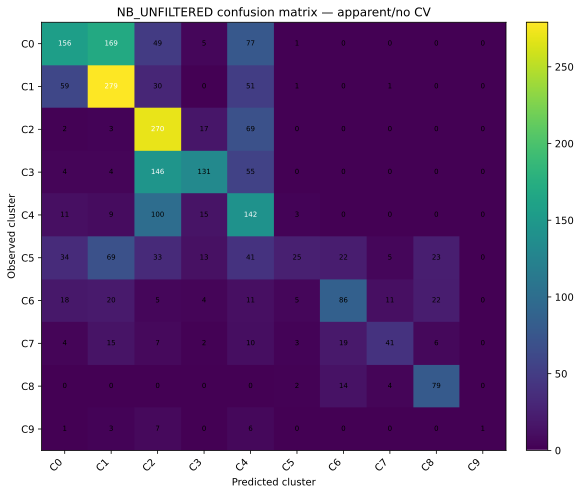

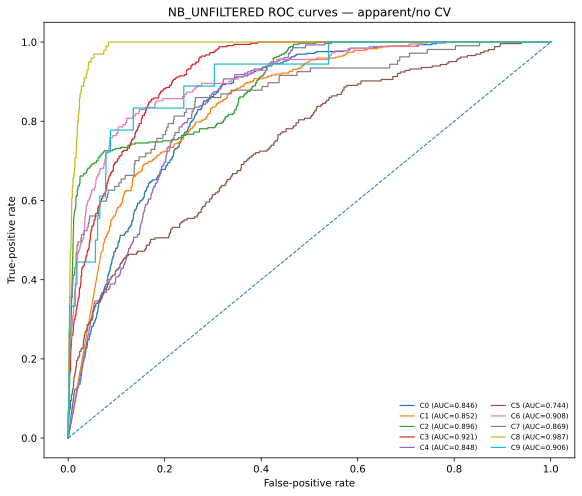

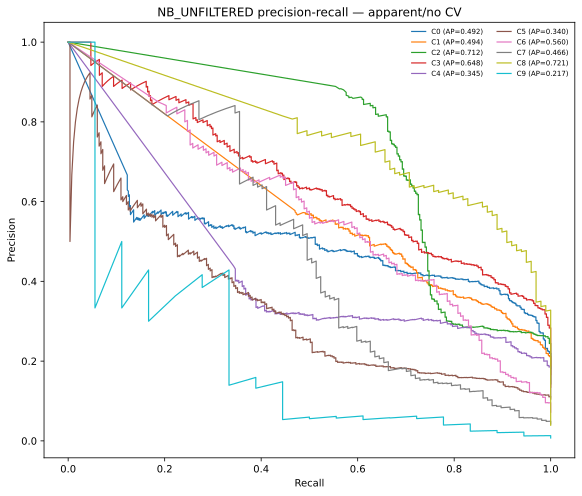


NB_UNFILTERED — APPARENT PERFORMANCE / NO CV
Participants:                 2,530
Clusters:                     10
Candidate variables:          1,390
Model variables:              1,387
Accuracy:                     0.4783
Balanced accuracy:            0.4448
Precision macro:              0.5958
Precision weighted:           0.5347
Recall macro:                 0.4448
Specificity macro:            0.9396
F1 macro:                     0.4373
F1 weighted:                  0.4585
ROC-AUC macro OVR:            0.8777
ROC-AUC weighted OVR:         0.8651
PR-AUC macro:                 0.4994
PR-AUC weighted:              0.5232
Multiclass log loss:          13.9845
Matthews correlation:         0.4070
Cohen kappa:                  0.3979
----------------------------------------------------------------------------------


,NB_UNFILTERED
model,NB_UNFILTERED
evaluation,apparent_in_sample_no_cv
feature_source,All variables present in NB_internal_operation...
N,2530
clusters,10
candidate_variables,1390
model_variables,1387
accuracy,0.478261
balanced_accuracy,0.4448
precision_macro,0.595753


,model,cluster,N,support,prevalence,predicted_n,predicted_fraction,TP,FP,FN,...,sensitivity_recall,specificity,NPV,F0.5,F1,F2,ROC_AUC_OVR,PR_AUC_average_precision,mean_probability_true_members,mean_probability_nonmembers
0,NB_UNFILTERED,C0,2530,457,0.180632,289,0.114229,156,133,301,...,0.341357,0.935842,0.865685,0.483571,0.418231,0.368446,0.845795,0.492420,0.340098,6.482564e-02
1,NB_UNFILTERED,C1,2530,421,0.166403,571,0.225692,279,292,142,...,0.662708,0.861546,0.927514,0.515712,0.562500,0.618625,0.851508,0.493518,0.660550,1.385853e-01
2,NB_UNFILTERED,C2,2530,361,0.142688,647,0.255731,270,377,91,...,0.747922,0.826187,0.951673,0.457782,0.535714,0.645624,0.896278,0.712032,0.747449,1.751604e-01
3,NB_UNFILTERED,C3,2530,340,0.134387,187,0.073913,131,56,209,...,0.385294,0.974429,0.910798,0.602022,0.497154,0.423400,0.921080,0.647808,0.387226,2.563454e-02
4,NB_UNFILTERED,C4,2530,280,0.110672,462,0.182609,142,320,138,...,0.507143,0.857778,0.933269,0.333647,0.382749,0.448799,0.848112,0.344901,0.507882,1.410355e-01
5,NB_UNFILTERED,C5,2530,265,0.104743,40,0.015810,25,15,240,...,0.094340,0.993377,0.903614,0.294118,0.163934,0.113636,0.743553,0.339509,0.094384,5.949419e-03
6,NB_UNFILTERED,C6,2530,182,0.071937,141,0.055731,86,55,96,...,0.472527,0.976576,0.959816,0.576408,0.532508,0.494822,0.908378,0.559520,0.476005,2.346857e-02
7,NB_UNFILTERED,C7,2530,107,0.042292,62,0.024506,41,21,66,...,0.383178,0.991333,0.973258,0.577465,0.485207,0.418367,0.869032,0.466326,0.383190,8.842389e-03
8,NB_UNFILTERED,C8,2530,99,0.039130,130,0.051383,79,51,20,...,0.797980,0.979021,0.991667,0.638126,0.689956,0.750951,0.987497,0.720702,0.798883,2.056710e-02
9,NB_UNFILTERED,C9,2530,18,0.007115,1,0.000395,1,0,17,...,0.055556,1.000000,0.993278,0.227273,0.105263,0.068493,0.906206,0.217281,0.055556,1.459676e-09


predicted_cluster,C0,C1,C2,C3,C4,C5,C6,C7,C8,C9
observed_cluster,,,,,,,,,,
C0,156,169,49,5,77,1,0,0,0,0
C1,59,279,30,0,51,1,0,1,0,0
C2,2,3,270,17,69,0,0,0,0,0
C3,4,4,146,131,55,0,0,0,0,0
C4,11,9,100,15,142,3,0,0,0,0
C5,34,69,33,13,41,25,22,5,23,0
C6,18,20,5,4,11,5,86,11,22,0
C7,4,15,7,2,10,3,19,41,6,0
C8,0,0,0,0,0,2,14,4,79,0



Los dos modelos terminaron correctamente.


In [5]:
# =============================================================================
# 5. EJECUTAR LOS DOS MODELOS AQUÍ
# =============================================================================
# Esta es la celda principal. Ejecuta primero las celdas 1–4 y después esta.

NB_FILTERED_RESULT = run_nb_logodds_model(
    model_name="NB_FILTERED",
    candidate_variables=NB_FILTERED_VARIABLES,
    feature_source=(
        "Variables with >=1 NB rule passing "
        "n_cluster_x, score and coverage filter"
    ),
)

NB_UNFILTERED_RESULT = run_nb_logodds_model(
    model_name="NB_UNFILTERED",
    candidate_variables=NB_UNFILTERED_VARIABLES,
    feature_source=(
        "All variables present in NB_internal_operations "
        "after scientific exclusions; no main filter"
    ),
)

print("\nLos dos modelos terminaron correctamente.")

In [6]:
# =============================================================================
# 6. COMPARACIÓN FILTRADO VS. SIN FILTRO
# =============================================================================

NB_GLOBAL_COMPARISON = pd.concat(
    [
        NB_FILTERED_RESULT[
            "global_metrics"
        ],
        NB_UNFILTERED_RESULT[
            "global_metrics"
        ],
    ],
    ignore_index=True,
)

NB_CLUSTER_COMPARISON = pd.concat(
    [
        NB_FILTERED_RESULT[
            "metrics_by_cluster"
        ],
        NB_UNFILTERED_RESULT[
            "metrics_by_cluster"
        ],
    ],
    ignore_index=True,
)

comparison_metrics = [
    "candidate_variables",
    "model_variables",
    "accuracy",
    "balanced_accuracy",
    "precision_macro",
    "precision_weighted",
    "recall_macro",
    "recall_weighted",
    "specificity_macro",
    "specificity_weighted",
    "F0.5_macro",
    "F1_macro",
    "F1_weighted",
    "F2_macro",
    "ROC_AUC_macro_OVR",
    "ROC_AUC_weighted_OVR",
    "ROC_AUC_micro_OVR",
    "PR_AUC_macro",
    "PR_AUC_weighted",
    "PR_AUC_micro",
    "multiclass_log_loss",
    "Matthews_correlation_coefficient",
    "Cohen_kappa",
]

NB_GLOBAL_COMPARISON_WIDE = (
    NB_GLOBAL_COMPARISON
    .set_index("model")[
        comparison_metrics
    ]
    .T
)

if {
    "NB_FILTERED",
    "NB_UNFILTERED",
}.issubset(
    NB_GLOBAL_COMPARISON_WIDE.columns
):
    NB_GLOBAL_COMPARISON_WIDE[
        "filtered_minus_unfiltered"
    ] = (
        NB_GLOBAL_COMPARISON_WIDE[
            "NB_FILTERED"
        ]
        - NB_GLOBAL_COMPARISON_WIDE[
            "NB_UNFILTERED"
        ]
    )

cluster_metric_columns = [
    "precision_PPV",
    "sensitivity_recall",
    "specificity",
    "F0.5",
    "F1",
    "F2",
    "ROC_AUC_OVR",
    "PR_AUC_average_precision",
]

NB_CLUSTER_COMPARISON_WIDE = (
    NB_CLUSTER_COMPARISON
    .pivot(
        index="cluster",
        columns="model",
        values=cluster_metric_columns,
    )
    .sort_index(
        key=lambda index: (
            index.map(cluster_sort_key)
        )
    )
)

comparison_excel_path = (
    OUTPUT_DIR
    / "NB_filtered_vs_unfiltered_comparison_no_cv.xlsx"
)

with pd.ExcelWriter(
    comparison_excel_path,
    engine="openpyxl",
) as writer:
    NB_GLOBAL_COMPARISON.to_excel(
        writer,
        sheet_name="Global_long",
        index=False,
    )
    NB_GLOBAL_COMPARISON_WIDE.to_excel(
        writer,
        sheet_name="Global_comparison",
    )
    NB_CLUSTER_COMPARISON.to_excel(
        writer,
        sheet_name="Cluster_long",
        index=False,
    )
    NB_CLUSTER_COMPARISON_WIDE.to_excel(
        writer,
        sheet_name="Cluster_comparison",
    )
    FILTER_SUMMARY.to_excel(
        writer,
        sheet_name="Variable_set_summary",
        index=False,
    )
    NB_VARIABLE_SET_AUDIT.to_excel(
        writer,
        sheet_name="Variable_membership",
        index=False,
    )
    NB_FILTERED_EVIDENCE.to_excel(
        writer,
        sheet_name="Rules_passing_filter",
        index=False,
    )

global_comparison_csv = (
    OUTPUT_DIR
    / "global_comparison_no_cv.csv"
)
cluster_comparison_csv = (
    OUTPUT_DIR
    / "cluster_comparison_no_cv.csv"
)

NB_GLOBAL_COMPARISON.to_csv(
    global_comparison_csv,
    index=False,
)
NB_CLUSTER_COMPARISON.to_csv(
    cluster_comparison_csv,
    index=False,
)

print("=" * 90)
print("COMPARACIÓN GLOBAL: NB FILTRADO VS. NB SIN FILTRO")
print("=" * 90)
display(
    NB_GLOBAL_COMPARISON_WIDE.style.format(
        precision=4
    )
)

print(
    "\nComparación por clúster:"
)
display(
    NB_CLUSTER_COMPARISON_WIDE.style.format(
        precision=4
    )
)

print("\nArchivos de comparación:")
print(" ", comparison_excel_path)
print(" ", global_comparison_csv)
print(" ", cluster_comparison_csv)

NB_COMPARISON_RESULT = {
    "global_long": NB_GLOBAL_COMPARISON,
    "global_wide": NB_GLOBAL_COMPARISON_WIDE,
    "cluster_long": NB_CLUSTER_COMPARISON,
    "cluster_wide": NB_CLUSTER_COMPARISON_WIDE,
    "variable_set_audit": NB_VARIABLE_SET_AUDIT,
    "comparison_excel": comparison_excel_path,
    "global_csv": global_comparison_csv,
    "cluster_csv": cluster_comparison_csv,
}

COMPARACIÓN GLOBAL: NB FILTRADO VS. NB SIN FILTRO


model,NB_FILTERED,NB_UNFILTERED,filtered_minus_unfiltered
candidate_variables,551.0000,1390.0000,-839.0000
model_variables,551.0000,1387.0000,-836.0000
accuracy,0.5933,0.4783,0.1150
balanced_accuracy,0.5544,0.4448,0.1096
precision_macro,0.6584,0.5958,0.0626
precision_weighted,0.6262,0.5347,0.0915
recall_macro,0.5544,0.4448,0.1096
recall_weighted,0.5933,0.4783,0.1150
specificity_macro,0.9530,0.9396,0.0134
specificity_weighted,0.9367,0.9178,0.0189



Comparación por clúster:



Archivos de comparación:
  /Users/cristianjuliocesarpadronmanrique/Desktop/ensanut preparation/prueba limpia/ENSANUT_HbA1c_complete_project/results/03_naive_bayes_filtered_vs_unfiltered_no_cv/NB_filtered_vs_unfiltered_comparison_no_cv.xlsx
  /Users/cristianjuliocesarpadronmanrique/Desktop/ensanut preparation/prueba limpia/ENSANUT_HbA1c_complete_project/results/03_naive_bayes_filtered_vs_unfiltered_no_cv/global_comparison_no_cv.csv
  /Users/cristianjuliocesarpadronmanrique/Desktop/ensanut preparation/prueba limpia/ENSANUT_HbA1c_complete_project/results/03_naive_bayes_filtered_vs_unfiltered_no_cv/cluster_comparison_no_cv.csv


## Objetos creados

Después de ejecutar las dos últimas celdas quedan disponibles:

```python
NB_FILTERED_RESULT
NB_UNFILTERED_RESULT
NB_GLOBAL_COMPARISON
NB_GLOBAL_COMPARISON_WIDE
NB_CLUSTER_COMPARISON
NB_CLUSTER_COMPARISON_WIDE
NB_COMPARISON_RESULT
```

Las carpetas de resultados son:

```text
results/
└── 03_naive_bayes_filtered_vs_unfiltered_no_cv/
    ├── nb_filtered/
    ├── nb_unfiltered/
    └── NB_filtered_vs_unfiltered_comparison_no_cv.xlsx
```

`NB_FILTERED` y `NB_UNFILTERED` se evalúan con los mismos participantes y sin CV.
La diferencia entre ambos modelos es únicamente el conjunto de variables.

In [7]:
3+3

6